# Зашумить изображение при помощи шума гаусса, постоянного шума.
# Протестировать медианный фильтр, фильтр гаусса, билатериальный фильтр, фильтр нелокальных средних с различными параметрами.
# Выяснить, какой фильтр показал лучший результат фильтрации шума.

In [7]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.metrics import mean_squared_error, structural_similarity

In [8]:
median_params = [3, 5, 7, 9]
gauss_params = [(3,3), (5,5), (7,7), (9,9)]
bilateral_params = [(5,50,50), (9,75,75), (9,150,150), (15,150,150)]
nlm_params = [5, 10, 20, 30]

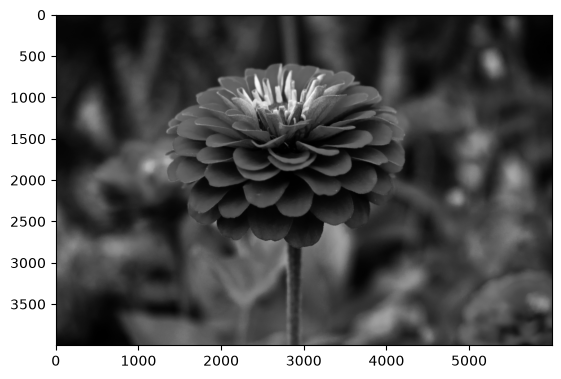

In [9]:
image = cv2.imread('img.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) 
plt.imshow(image_gray, cmap="gray")

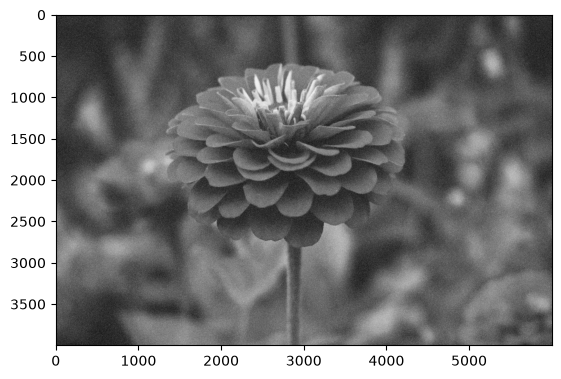

In [10]:
mean = 0
stddev = 100
noise_gauss = np.zeros(image_gray.shape, np.uint8)
cv2.randn(noise_gauss, mean, stddev)
image_noise_gauss = cv2.add(image_gray, noise_gauss)
plt.imshow(image_noise_gauss, cmap="gray")

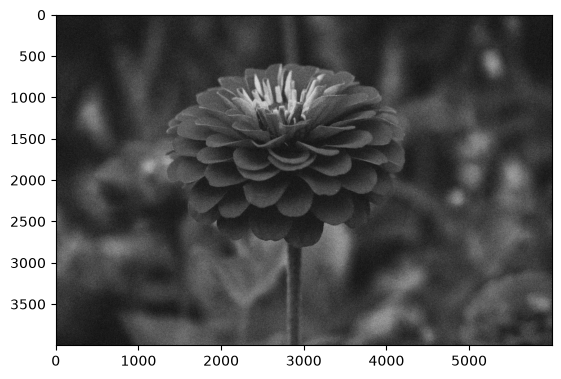

In [11]:
# 0 represents black (pepper)
# 100 represents white (salt)
# noise =  np.random.randint(0, 101, size = (image_gray.shape[0], image_gray.shape[1]), dtype=int)
# zeros_pixel = np.where(noise == 0)
# ones_pixel = np.where(noise == 100)
# image_sp = np.ones(image_gray.shape, np.uint8) * 128
# image_sp = image_gray.copy()
# image_sp[zeros_pixel] = 0
# image_sp[ones_pixel] = 255
# plt.imshow(image_sp, cmap="gray")


low, high = -100, 100
noise_uniform = np.random.uniform(low, high, size=image_gray.shape)
image_noise_uniform = np.clip(image_gray.astype(np.float64) + noise_uniform, 0, 255).astype(np.uint8)
plt.imshow(image_noise_uniform, cmap="gray")

gauss noise, k=3: MSE=845.0423, SSIM=0.1536


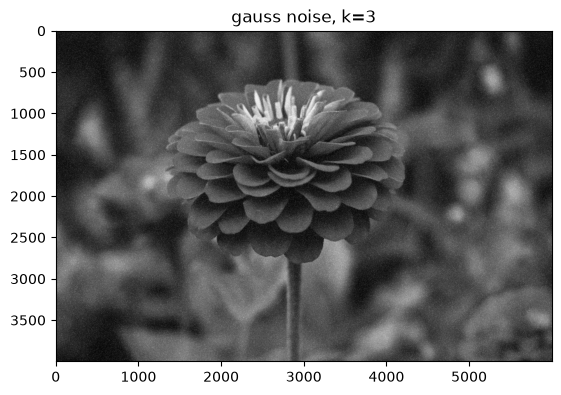

gauss noise, k=5: MSE=334.3349, SSIM=0.3650


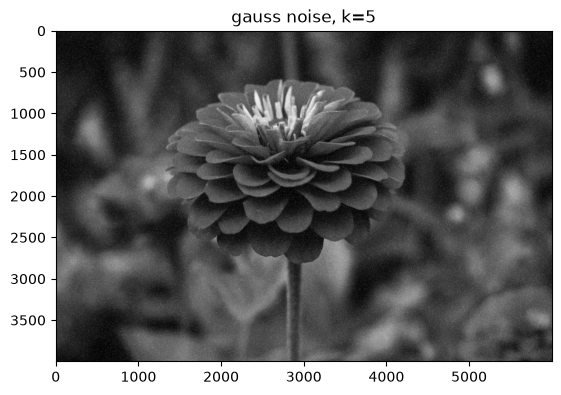

gauss noise, k=7: MSE=189.6266, SSIM=0.5437


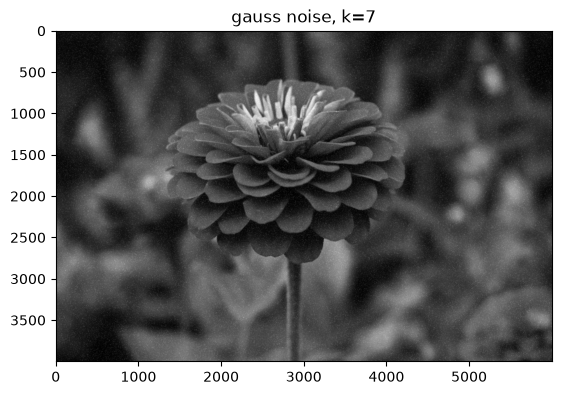

gauss noise, k=9: MSE=132.3044, SSIM=0.6542


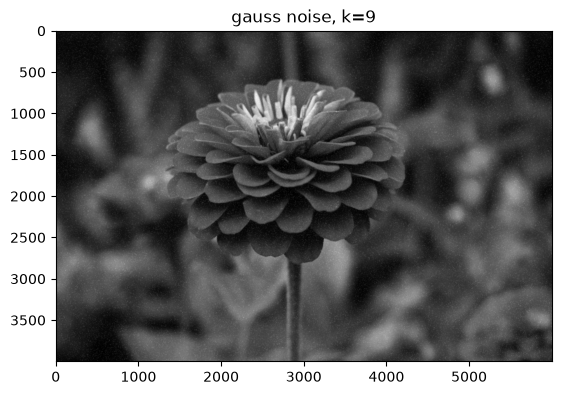

uniform noise, k=3: MSE=2537.2915, SSIM=0.0313


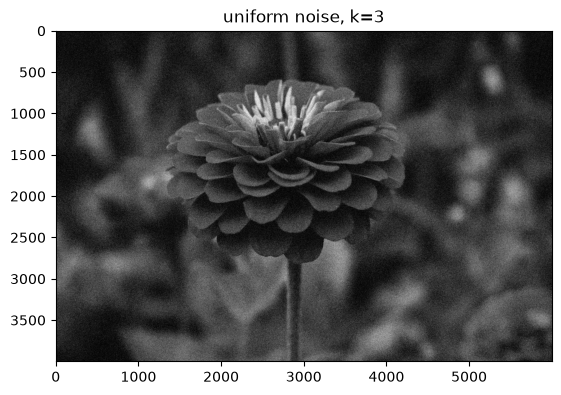

uniform noise, k=5: MSE=2537.2915, SSIM=0.0313


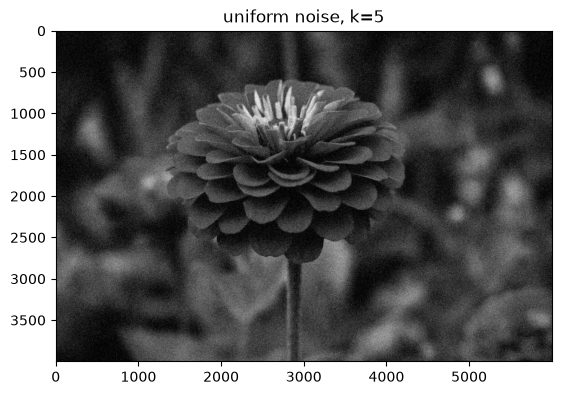

uniform noise, k=7: MSE=2537.2915, SSIM=0.0313


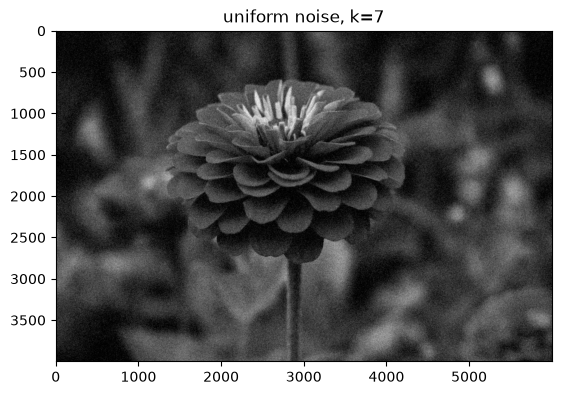

uniform noise, k=9: MSE=2537.2915, SSIM=0.0313


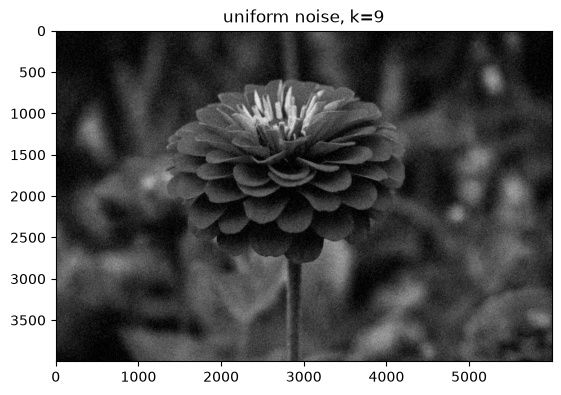

In [12]:
#median filtering

for k in median_params:
    res = cv2.medianBlur(image_noise_gauss, k)
    mse_val = mean_squared_error(image_gray, res)
    (ssim_val, diff) = structural_similarity(image_gray, res, full=True)
    print(f'gauss noise, k={k}: MSE={mse_val:.4f}, SSIM={ssim_val:.4f}')
    plt.imshow(res, cmap='gray')
    plt.title(f'gauss noise, k={k}')
    plt.show()

for k in median_params:
    res = cv2.medianBlur(image_noise_uniform, k)
    mse_uniform = mean_squared_error(image_gray, image_noise_uniform)
    (ssim_uniform, diff) = structural_similarity(image_gray, image_noise_uniform, full=True)
    print(f'uniform noise, k={k}: MSE={mse_uniform:.4f}, SSIM={ssim_uniform:.4f}')
    plt.imshow(res, cmap='gray')
    plt.title(f'uniform noise, k={k}')
    plt.show()


gauss noise, ksize=(3, 3): MSE=1928.1688, SSIM=0.1414


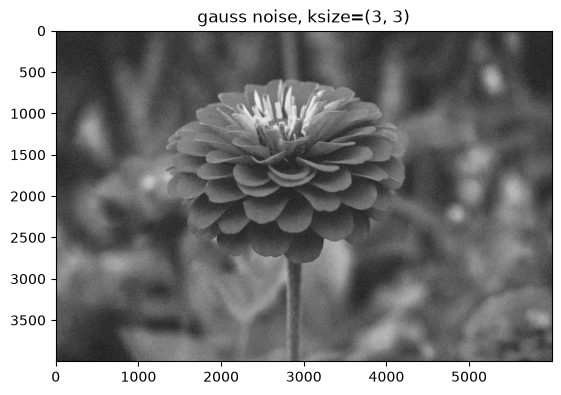

gauss noise, ksize=(5, 5): MSE=1730.9777, SSIM=0.2306


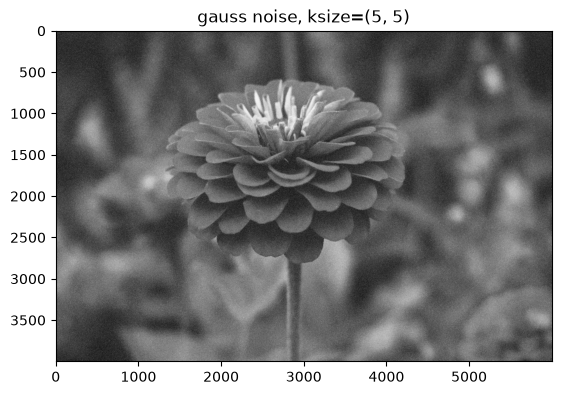

gauss noise, ksize=(7, 7): MSE=1629.4295, SSIM=0.3476


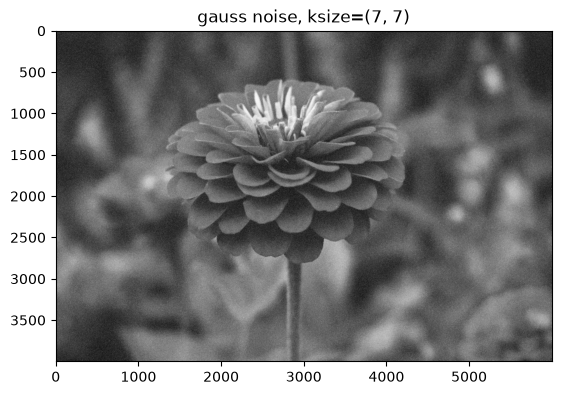

gauss noise, ksize=(9, 9): MSE=1593.5107, SSIM=0.4210


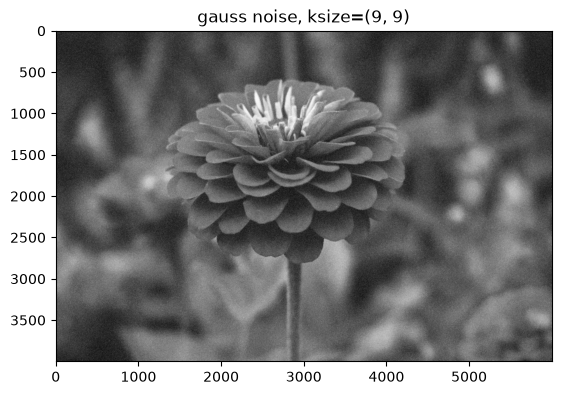

uniform noise, ksize=(3, 3): MSE=448.1514, SSIM=0.1814


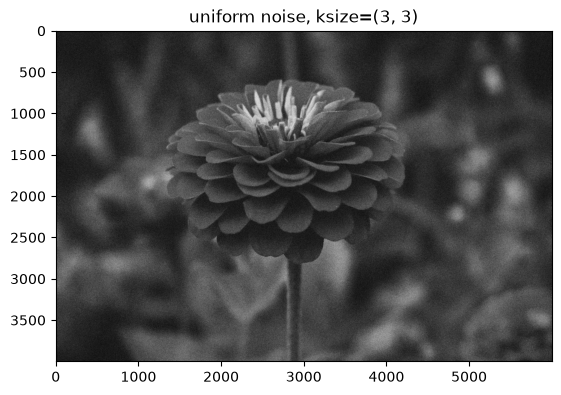

uniform noise, ksize=(5, 5): MSE=289.6549, SSIM=0.2963


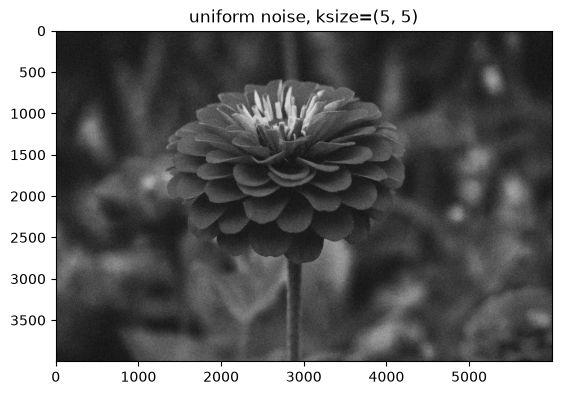

uniform noise, ksize=(7, 7): MSE=207.4134, SSIM=0.4390


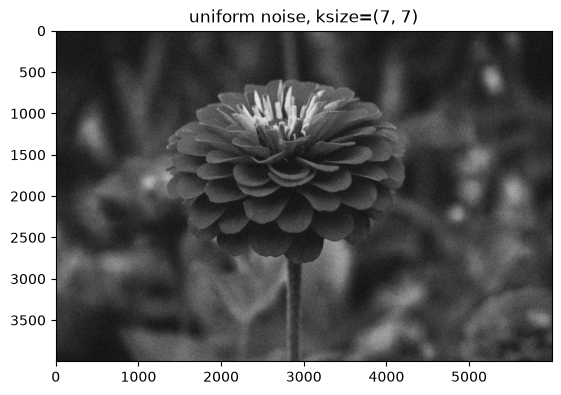

uniform noise, ksize=(9, 9): MSE=178.3039, SSIM=0.5240


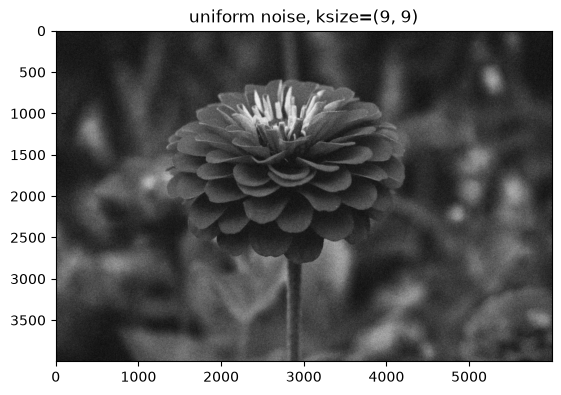

In [13]:
for ksize in gauss_params:
    res = cv2.GaussianBlur(image_noise_gauss, ksize, 0)
    mse_val = mean_squared_error(image_gray, res)
    (ssim_val, diff) = structural_similarity(image_gray, res, full=True)
    print(f'gauss noise, ksize={ksize}: MSE={mse_val:.4f}, SSIM={ssim_val:.4f}')
    plt.imshow(res, cmap='gray')
    plt.title(f'gauss noise, ksize={ksize}')
    plt.show()
for ksize in gauss_params:
    res = cv2.GaussianBlur(image_noise_uniform, ksize, 0)
    mse_val = mean_squared_error(image_gray, res)
    (ssim_val, diff) = structural_similarity(image_gray, res, full=True)
    print(f'uniform noise, ksize={ksize}: MSE={mse_val:.4f}, SSIM={ssim_val:.4f}')

    plt.imshow(res, cmap='gray')
    plt.title(f'uniform noise, ksize={ksize}')
    plt.show()
    

gauss noise, d=5, sc=50, ss=50: MSE=3050.1884, SSIM=0.0427


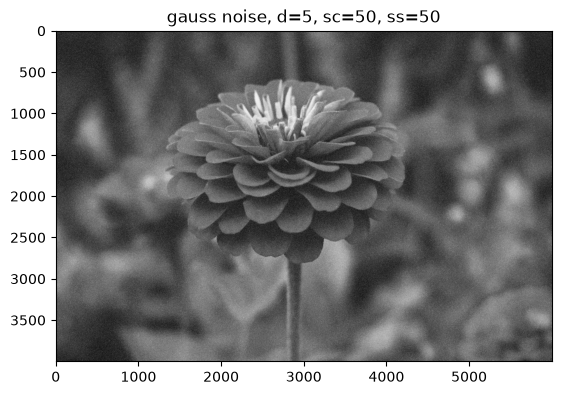

gauss noise, d=9, sc=75, ss=75: MSE=1788.7017, SSIM=0.1045


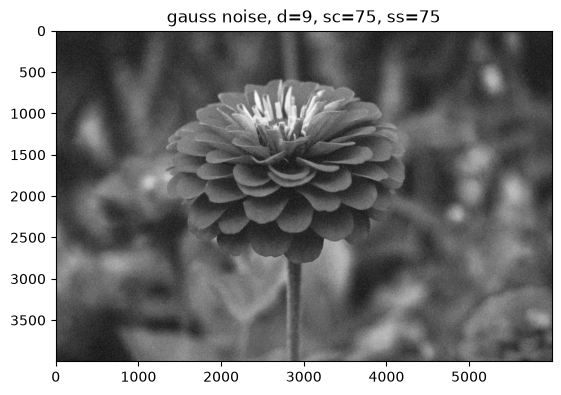

gauss noise, d=9, sc=150, ss=150: MSE=1364.8454, SSIM=0.3524


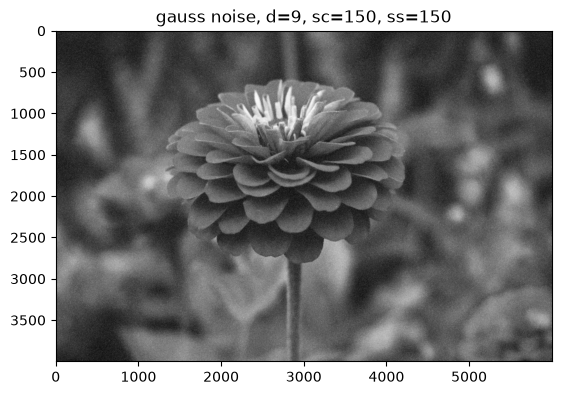

gauss noise, d=15, sc=150, ss=150: MSE=1311.9056, SSIM=0.4153


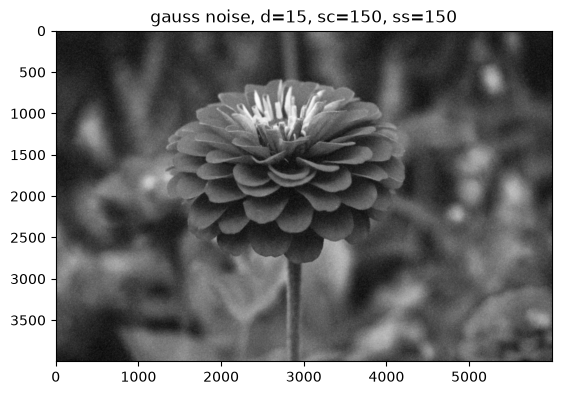

uniform noise, d=5, sc=50, ss=50: MSE=1196.9906, SSIM=0.0711


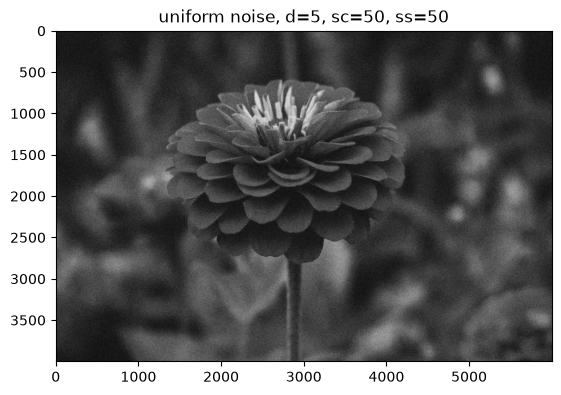

uniform noise, d=9, sc=75, ss=75: MSE=488.2265, SSIM=0.1793


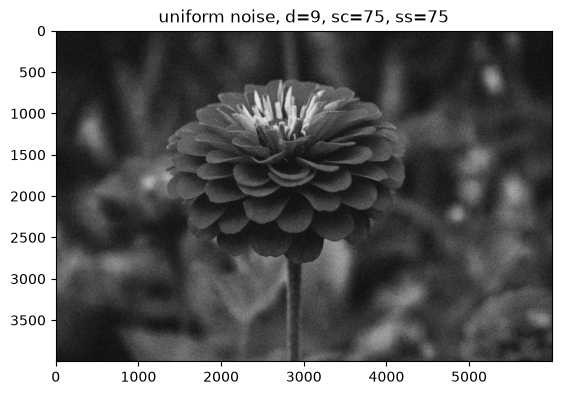

uniform noise, d=9, sc=150, ss=150: MSE=186.2824, SSIM=0.4643


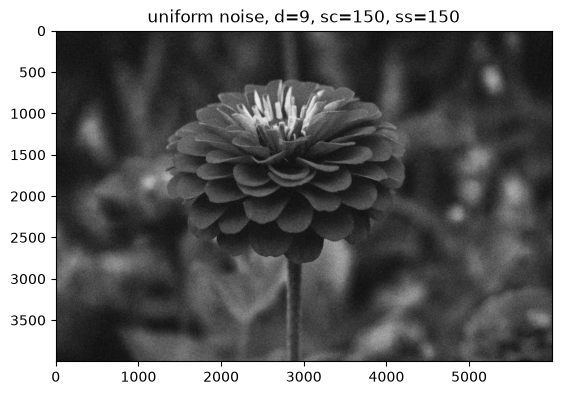

uniform noise, d=15, sc=150, ss=150: MSE=150.0409, SSIM=0.5547


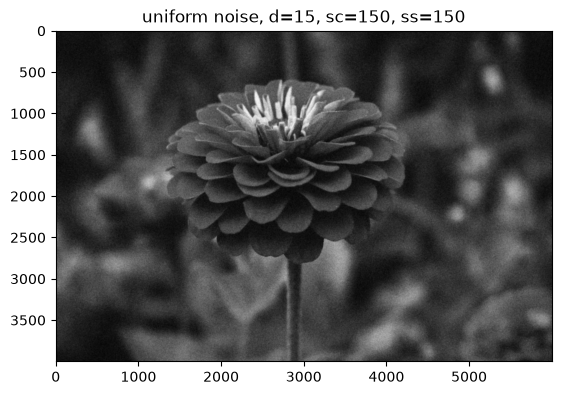

In [14]:
for d, sigma_color, sigma_space in bilateral_params:
    res = cv2.bilateralFilter(image_noise_gauss, d, sigma_color, sigma_space)
    mse_val = mean_squared_error(image_gray, res)
    (ssim_val, diff) = structural_similarity(image_gray, res, full=True)
    print(f'gauss noise, d={d}, sc={sigma_color}, ss={sigma_space}: MSE={mse_val:.4f}, SSIM={ssim_val:.4f}')
    plt.imshow(res, cmap='gray')
    plt.title(f'gauss noise, d={d}, sc={sigma_color}, ss={sigma_space}')
    plt.show()

for d, sigma_color, sigma_space in bilateral_params:
    res = cv2.bilateralFilter(image_noise_uniform, d, sigma_color, sigma_space)
    mse_val = mean_squared_error(image_gray, res)
    (ssim_val, diff) = structural_similarity(image_gray, res, full=True)
    print(f'uniform noise, d={d}, sc={sigma_color}, ss={sigma_space}: MSE={mse_val:.4f}, SSIM={ssim_val:.4f}')
    plt.imshow(res, cmap='gray')
    plt.title(f'uniform noise, d={d}, sc={sigma_color}, ss={sigma_space}')
    plt.show()
    

gauss noise, h=5: MSE=4501.2754, SSIM=0.0259


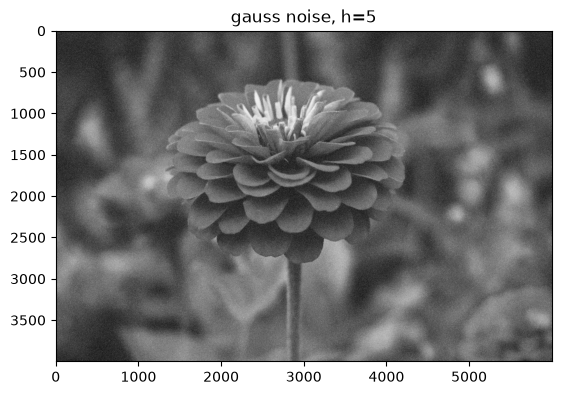

gauss noise, h=10: MSE=4501.1383, SSIM=0.0261


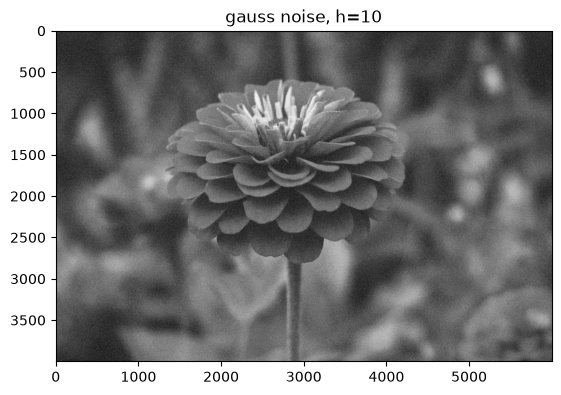

gauss noise, h=20: MSE=4488.9830, SSIM=0.0289


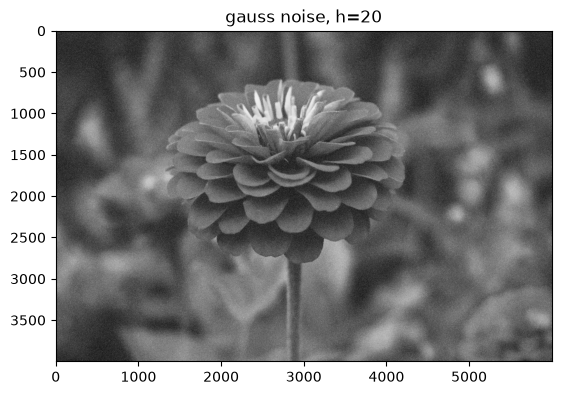

gauss noise, h=30: MSE=2782.6317, SSIM=0.0834


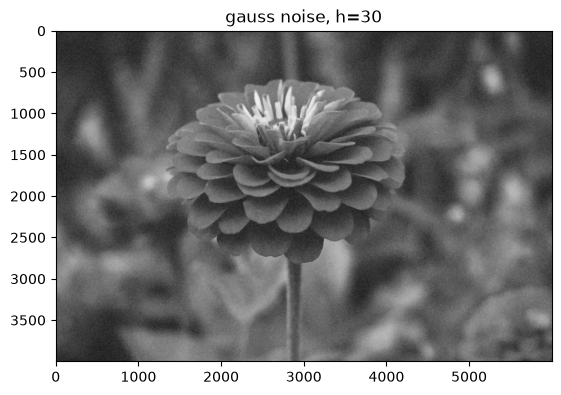

uniform noise, h=5: MSE=2537.2915, SSIM=0.0313


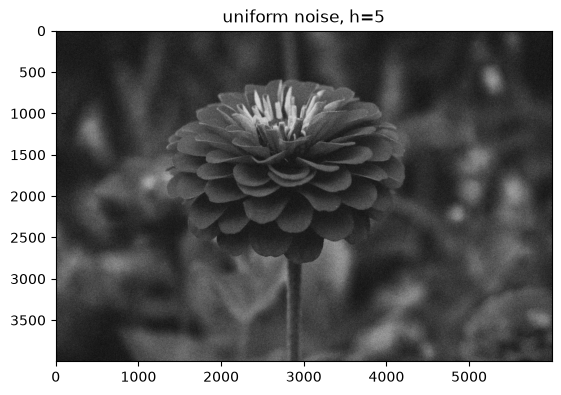

uniform noise, h=10: MSE=2537.2915, SSIM=0.0313


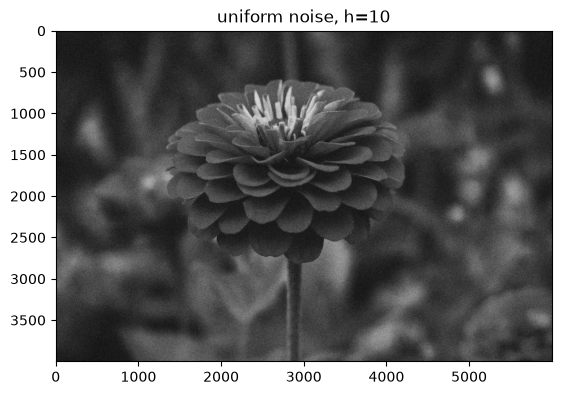

uniform noise, h=20: MSE=2390.3759, SSIM=0.0389


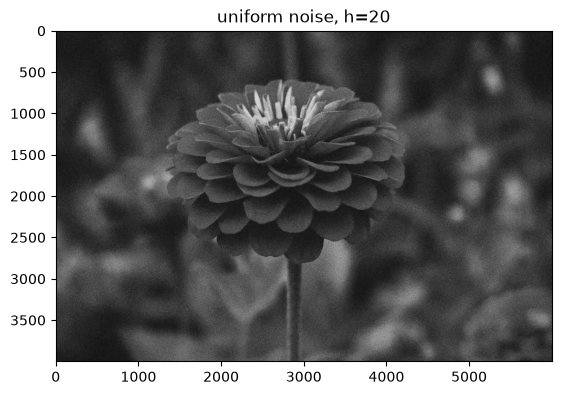

uniform noise, h=30: MSE=862.7714, SSIM=0.2297


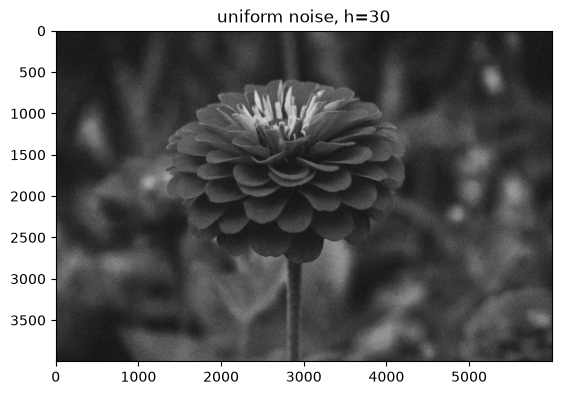

In [15]:
for h in nlm_params:
    res = cv2.fastNlMeansDenoising(image_noise_gauss, h=h)
    mse_val = mean_squared_error(image_gray, res)
    (ssim_val, diff) = structural_similarity(image_gray, res, full=True)
    print(f'gauss noise, h={h}: MSE={mse_val:.4f}, SSIM={ssim_val:.4f}')
    plt.imshow(res, cmap='gray');
    plt.title(f'gauss noise, h={h}')
    plt.show()

for h in nlm_params:
    res = cv2.fastNlMeansDenoising(image_noise_uniform, h=h)
    mse_val = mean_squared_error(image_gray, res)
    (ssim_val, diff) = structural_similarity(image_gray, res, full=True)
    print(f'uniform noise, h={h}: MSE={mse_val:.4f}, SSIM={ssim_val:.4f}')
    plt.imshow(res, cmap='gray')
    plt.title(f'uniform noise, h={h}')
    plt.show()

In [ ]:
#comparing using SSIM

results_gauss_noise = {}
results_noise_uniform = {}

for k in median_params:
    res = cv2.medianBlur(image_noise_gauss, k)
    (ssim_val, diff) = structural_similarity(image_gray, res, full=True)
    results_gauss_noise[f'median k={k}'] = ssim_val

    res = cv2.medianBlur(image_noise_uniform, k)
    (ssim_val, diff) = structural_similarity(image_gray, res, full=True)
    results_noise_uniform[f'median k={k}'] = ssim_val

for ksize in gauss_params:
    res = cv2.GaussianBlur(image_noise_gauss, ksize, 0)
    (ssim_val, diff) = structural_similarity(image_gray, res, full=True)
    results_gauss_noise[f'gaussian ksize={ksize}'] = ssim_val

    res = cv2.GaussianBlur(image_noise_uniform, ksize, 0)
    (ssim_val, diff) = structural_similarity(image_gray, res, full=True)
    results_noise_uniform[f'gaussian ksize={ksize}'] = ssim_val

for d, sigma_color, sigma_space in bilateral_params:
    res = cv2.bilateralFilter(image_noise_gauss, d, sigma_color, sigma_space)
    (ssim_val, diff) = structural_similarity(image_gray, res, full=True)
    results_gauss_noise[f'bilateral d={d},sc={sigma_color},ss={sigma_space}'] = ssim_val

    res = cv2.bilateralFilter(image_noise_uniform, d, sigma_color, sigma_space)
    (ssim_val, diff) = structural_similarity(image_gray, res, full=True)
    results_noise_uniform[f'bilateral d={d},sc={sigma_color},ss={sigma_space}'] = ssim_val

for h in nlm_params:
    res = cv2.fastNlMeansDenoising(image_noise_gauss, h=h)
    (ssim_val, diff) = structural_similarity(image_gray, res, full=True)
    results_gauss_noise[f'nlm h={h}'] = ssim_val

    res = cv2.fastNlMeansDenoising(image_noise_uniform, h=h)
    (ssim_val, diff) = structural_similarity(image_gray, res, full=True)
    results_noise_uniform[f'nlm h={h}'] = ssim_val

best_gauss = max(results_gauss_noise, key=results_gauss_noise.get)
best_uniform = max(results_noise_uniform, key=results_noise_uniform.get)

print(f'gauss noise best: {best_gauss}, SSIM={results_gauss_noise[best_gauss]:.4f}')
print(f'uniform noise best: {best_uniform}, SSIM={results_noise_uniform[best_uniform]:.4f}')

NameError: name 'results_sp_noise' is not defined